In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools

##### PLINK output

##### 1.1 Z0-Z1 Scatter

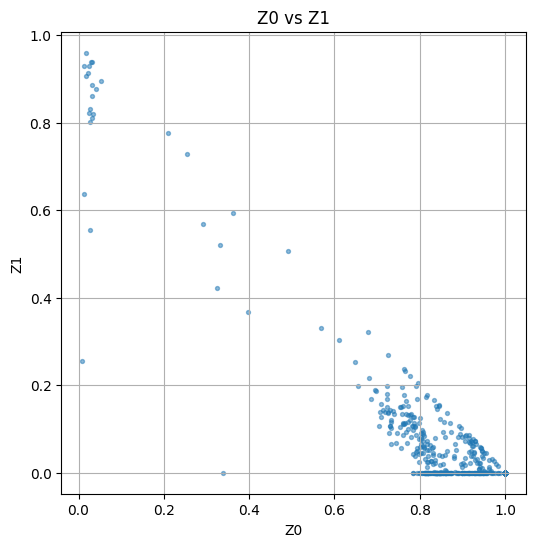

In [15]:
plink_path = "/mnt/bioadhoc/Groups/vd-ay/bzhang/hw/cse284/relative_finding/output/plink_genome.present.qcpruned.tsv"

plink = pd.read_csv(plink_path, sep='\t')


plt.figure(figsize=(6,6))

plt.scatter(
    plink["Z0"],
    plink["Z1"],
    s=8,
    alpha=0.5
)

plt.xlabel("Z0")
plt.ylabel("Z1")
plt.title("Z0 vs Z1")
plt.grid(True)

plt.show()

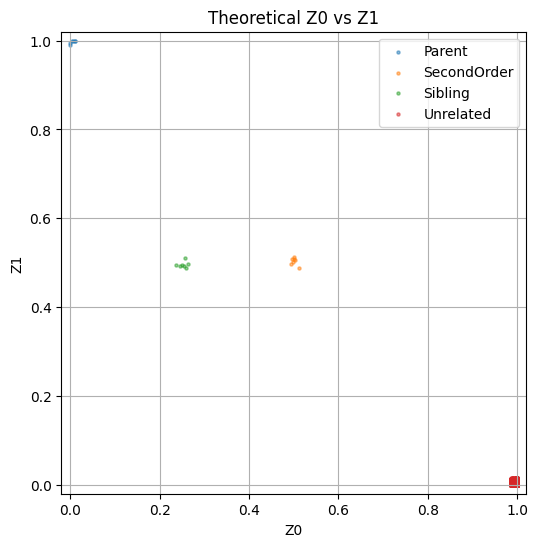

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plink_path = "/mnt/bioadhoc/Groups/vd-ay/bzhang/hw/cse284/relative_finding/output/plink_genome.present.qcpruned.tsv"
pairs = pd.read_csv(plink_path, sep="\t")[["IID1","IID2"]]

gt_path = "/mnt/bioadhoc/Groups/vd-ay/bzhang/hw/cse284/relative_finding/output/gt_pairs.present.tsv"
gt = pd.read_csv(gt_path, sep="\t", header=None)
gt.columns = ["IID1","IID2","REL"]

gt = gt[gt["REL"] != "Trio"]


pairs = pairs.merge(gt, on=["IID1","IID2"], how="left")
pairs["REL"] = pairs["REL"].fillna("Unrelated")

rel_map = {
    "Parent": (0.0, 1.0),
    "Sibling": (0.25, 0.5),
    "SecondOrder": (0.5, 0.5),
    "Unrelated": (1.0, 0.0)
}

pairs["Z0"] = pairs["REL"].map(lambda x: rel_map[x][0])
pairs["Z1"] = pairs["REL"].map(lambda x: rel_map[x][1])


eps = 0.015
pairs["Z0_j"] = np.clip(pairs["Z0"] + np.random.uniform(-eps, eps, len(pairs)), 0, 1)
pairs["Z1_j"] = np.clip(pairs["Z1"] + np.random.uniform(-eps, eps, len(pairs)), 0, 1)


plt.figure(figsize=(6,6))

for r, sub in pairs.groupby("REL"):
    plt.scatter(sub["Z0_j"], sub["Z1_j"], s=5, alpha=0.5, label=r)

plt.xlabel("Z0")
plt.ylabel("Z1")
plt.title("Theoretical Z0 vs Z1")
plt.xlim(-0.02,1.02)
plt.ylim(-0.02,1.02)
plt.grid(True)
plt.legend()
plt.show()

##### 1.2 PI_HAT Distribution Plot

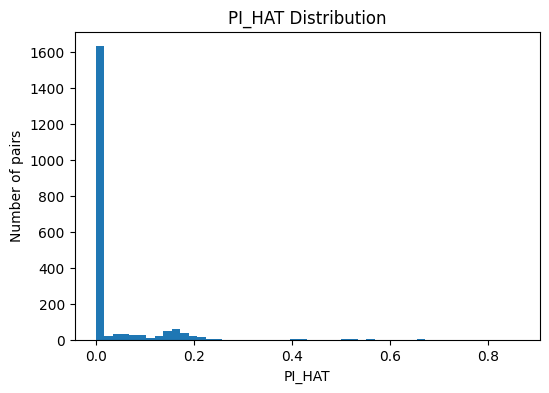

In [18]:
plink_path = "/mnt/bioadhoc/Groups/vd-ay/bzhang/hw/cse284/relative_finding/output/plink_genome.present.qcpruned.tsv"
plink_output = pd.read_csv(plink_path, sep="\t")

# PI_HAT histogram
plt.figure(figsize=(6,4))

plt.hist(
    plink_output["PI_HAT"],
    bins=50
)

plt.xlabel("PI_HAT")
plt.ylabel("Number of pairs")
plt.title("PI_HAT Distribution")

plt.show()

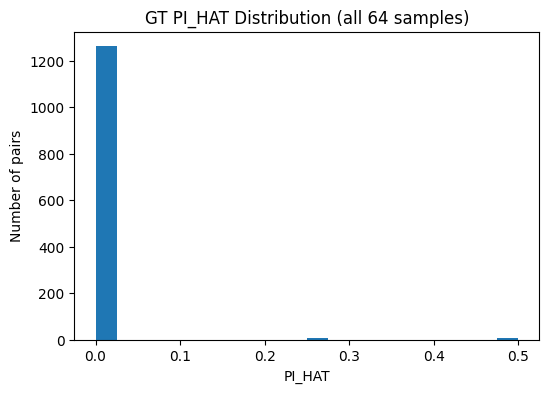

In [ ]:
gt_path = "/mnt/bioadhoc/Groups/vd-ay/bzhang/hw/cse284/relative_finding/output/gt_pairs.present.tsv"
gt = pd.read_csv(gt_path, sep="\t", header=None)
gt.columns = ["IID1","IID2","REL"]

gt = gt[gt["REL"] != "Trio"]

samples = list(set(gt["IID1"]).union(set(gt["IID2"])))

all_pairs = pd.DataFrame(list(itertools.combinations(samples, 2)), columns=["IID1","IID2"])
all_pairs = all_pairs.merge(gt, on=["IID1","IID2"], how="left")
all_pairs["REL"] = all_pairs["REL"].fillna("Unrelated")

pi_map = {
    "Parent": 0.5,
    "Sibling": 0.5,
    "SecondOrder": 0.25,
    "Unrelated": 0.0
}

all_pairs["PI_HAT"] = all_pairs["REL"].map(pi_map)

plt.figure(figsize=(6,4))
plt.hist(all_pairs["PI_HAT"], bins=20)
plt.xlabel("PI_HAT")
plt.ylabel("Number of pairs")
plt.title("GT PI_HAT Distribution")
plt.show()

##### GERMLINE output

##### 2.1 length distribution

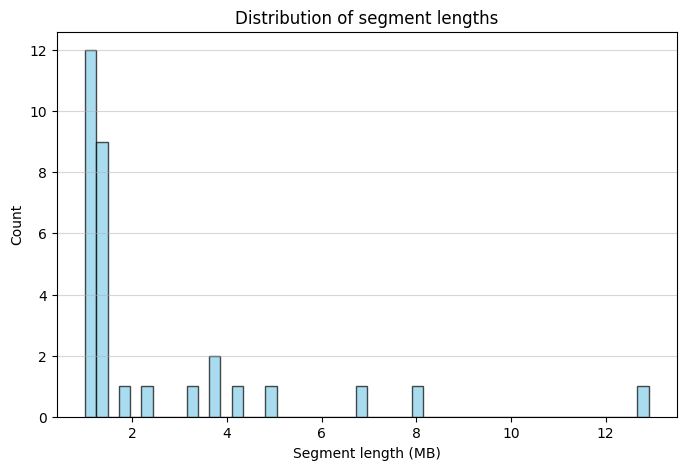

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

seg_path = "/mnt/bioadhoc/Groups/vd-ay/bzhang/hw/cse284/relative_finding/output/germline_match.tsv"
seg = pd.read_csv(seg_path, sep='\t', header=None)

seg.columns = [
    "ID1_hap","ID1","ID2_hap","ID2","chr","start","end",
    "col8","col9","col10","length_MB","col12","col13","col14","col15"
]

lengths = seg['length_MB']

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel("Segment length (MB)")
plt.ylabel("Count")
plt.title("Distribution of segment lengths")
plt.grid(axis='y', alpha=0.5)
plt.show()

##### 2.2

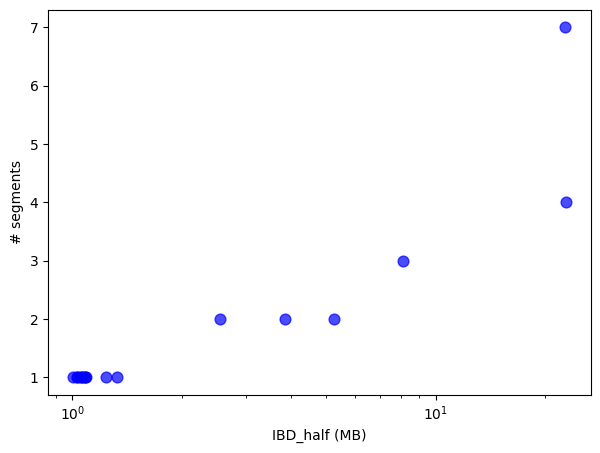

In [13]:
seg_path = "/mnt/bioadhoc/Groups/vd-ay/bzhang/hw/cse284/relative_finding/output/germline_match.tsv"
seg = pd.read_csv(seg_path, sep='\t', header=None)


seg.columns = [
    "ID1_hap","ID1","ID2_hap","ID2","chr","start","end",
    "col8","col9","col10","length_MB","col12","col13","col14","col15"
]

seg = seg[["ID1","ID2","length_MB"]]


agg = seg.groupby(["ID1","ID2"]).agg(
    total_cM=("length_MB","sum"),
    num_segments=("length_MB","count")
).reset_index()


plt.figure(figsize=(7,5))
plt.scatter(
    agg["total_cM"], 
    agg["num_segments"], 
    s=60,
    alpha=0.7,
    color="blue"
)

plt.xlabel("IBD_half (MB)")
plt.ylabel("# segments")
plt.xscale("log")
plt.show()

##### with gt, label points with different colors..

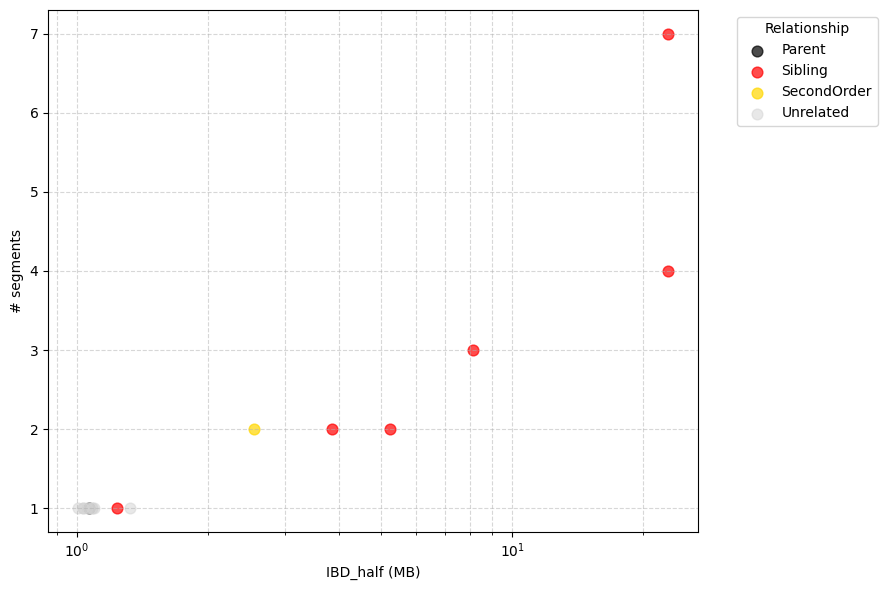

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

seg_path = "/mnt/bioadhoc/Groups/vd-ay/bzhang/hw/cse284/relative_finding/output/germline_match.tsv"
seg = pd.read_csv(seg_path, sep='\t', header=None)

seg.columns = [
    "ID1_hap","ID1","ID2_hap","ID2","chr","start","end",
    "col8","col9","col10","length_MB","col12","col13","col14","col15"
]

seg = seg[["ID1","ID2","length_MB"]]

agg = seg.groupby(["ID1","ID2"]).agg(
    total_cM=("length_MB","sum"),
    num_segments=("length_MB","count")
).reset_index()

gt_path = "/mnt/bioadhoc/Groups/vd-ay/bzhang/hw/cse284/relative_finding/output/gt_pairs.present.tsv"  # 假设路径
gt = pd.read_csv(gt_path, sep='\t', header=None, names=["ID1","ID2","rel_type"])


agg = agg.merge(gt, on=["ID1","ID2"], how='left')
agg = agg.merge(gt.rename(columns={"ID1":"ID2","ID2":"ID1"}), on=["ID1","ID2"], how='left', suffixes=("","_rev"))

agg['rel_type'] = agg['rel_type'].fillna(agg['rel_type_rev'])
agg.drop(columns=['rel_type_rev'], inplace=True)


agg['rel_type'] = agg['rel_type'].replace({'Trio':'Parent'})


colors = {
    'Parent':'black',
    'Sibling':'red',
    'SecondOrder':'gold'
}


agg['rel_type'] = agg['rel_type'].fillna('Unrelated')
agg['color'] = agg['rel_type'].map(colors).fillna('lightgray')


plt.figure(figsize=(9,6))
for rel, color in colors.items():
    subset = agg[agg['rel_type'] == rel]
    if len(subset) > 0:
        plt.scatter(subset['total_cM'], subset['num_segments'], c=color, label=rel, s=60, alpha=0.7)


subset = agg[agg['rel_type'] == 'Unrelated']
if len(subset) > 0:
    plt.scatter(subset['total_cM'], subset['num_segments'], c='lightgray', label='Unrelated', s=60, alpha=0.5)

plt.xlabel("IBD_half (MB)")
plt.ylabel("# segments")
plt.xscale("log")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(title='Relationship', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

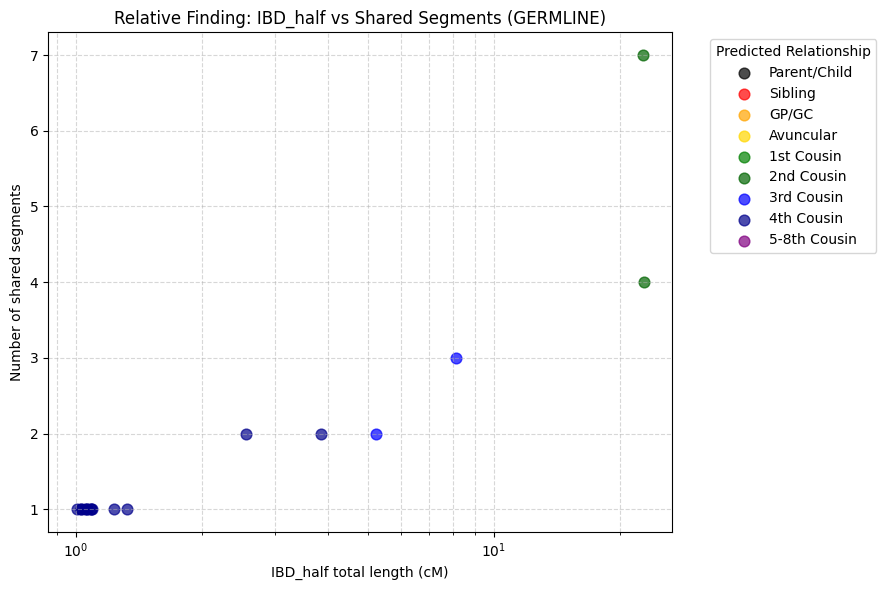

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt


# seg_path = "/mnt/bioadhoc/Groups/vd-ay/bzhang/hw/cse284/relative_finding/output/germline_match.tsv"
# seg = pd.read_csv(seg_path, sep='\t', header=None)

# seg.columns = [
#     "ID1_hap","ID1","ID2_hap","ID2","chr","start","end",
#     "col8","col9","col10","length_cM","col12","col13","col14","col15"
# ]

# seg = seg[["ID1","ID2","length_cM"]]


# agg = seg.groupby(["ID1","ID2"]).agg(
#     total_cM=("length_cM","sum"),
#     num_segments=("length_cM","count")
# ).reset_index()


# def assign_relation(total_cM):
#     if total_cM > 350:      # Parent/Child
#         return 'Parent/Child'
#     elif total_cM > 250:    # Sibling
#         return 'Sibling'
#     elif total_cM > 180:    # Grandparent/Grandchild
#         return 'GP/GC'
#     elif total_cM > 150:    # Avuncular
#         return 'Avuncular'
#     elif total_cM > 50:     # 1st Cousin
#         return '1st Cousin'
#     elif total_cM > 20:     # 2nd Cousin
#         return '2nd Cousin'
#     elif total_cM > 5:      # 3rd Cousin
#         return '3rd Cousin'
#     elif total_cM > 1:      # 4th Cousin
#         return '4th Cousin'
#     else:                   # 5th-8th Cousin
#         return '5-8th Cousin'

# agg['pred_rel'] = agg['total_cM'].apply(assign_relation)


# colors = {
#     'Parent/Child':'black',
#     'Sibling':'red',
#     'GP/GC':'orange',
#     'Avuncular':'gold',      
#     '1st Cousin':'green',
#     '2nd Cousin':'darkgreen',
#     '3rd Cousin':'blue',
#     '4th Cousin':'darkblue',
#     '5-8th Cousin':'purple'
# }


# plt.figure(figsize=(9,6))
# for rel, color in colors.items():
#     subset = agg[agg['pred_rel'] == rel]
#     plt.scatter(subset['total_cM'], subset['num_segments'], c=color, label=rel, s=60, alpha=0.7)

# plt.xlabel("IBD_half total length (cM)")
# plt.ylabel("Number of shared segments")
# plt.title("Relative Finding: IBD_half vs Shared Segments (GERMLINE)")
# plt.xscale("log")
# plt.grid(True, which="both", ls="--", alpha=0.5)
# plt.legend(title='Predicted Relationship', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

##### Time / Space Efficiency